In [365]:
import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
import re
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [366]:
name = 'spSpec-51910-0275-445.Sbmm.out'
name = 'spSpec-51877-0410-217.Sbmm.out'
#name = 'header_test.out'

In [367]:
hdr_params = ["[arq_obs]","[arq_base]","[arq_masks]","[arq_config]","[N_base]","[N_YAV_components = # of components with extra extinction!]",
              "[i_FitPowerLaw (1/0 = Yes/No)]","[alpha_PowerLaw]","[red_law_option]","[q_norm = A(l_norm)/A(V)]", ## Some input info
              
              "[l_ini (A)]","[l_fin (A)]","[dl    (A)]     (OBS: dl_cushion =    50.00 A)", ## (Re)Sampling Parameters

              "[l_norm (A) - for base]","[llow_norm (A) - window for f_obs]","[lupp_norm (A) - window for f_obs]","[fobs_norm (in input units)]", ## Normalization info
              
              "[llow_SN (A) - window for S/N]","[lupp_SN (A) - window for S/N]","[S/N in S/N window]","[S/N in norm. window]","[S/N_err in S/N window]",
              "[S/N_err in norm. window]","[fscale_chi2]", ## S/N

              "[idum_orig]","[NOl_eff]","[Nl_eff]","[Ntot_cliped & clip_method]","[Nglobal_steps]","[N_chains]","[NEX0s_base = N_base in EX0s-fits]",
              "[Clip-Bug, RC-Crash & Burn-In warning-flags, n_censored_weights, wei_nsig_threshold & wei_limit]",
              "[idt_all, wdt_TotTime, wdt_UsrTime & wdt_SysTime (sec)]", ## etc...

              "[chi2/Nl_eff]","[adev (%)]","[sum-of-x (%)]","[Flux_tot (units of input spectrum!)]","[Mini_tot (???)]","[Mcor_tot (???)]",
              "[v0_min  (km/s)]","[vd_min  (km/s)]","[AV_min  (mag)]","[YAV_min (mag)]", ## Synthesis Results - Best model ##


              ]



hdr_titles = ['## OUTPUT of StarlightChains_v05.for    [Cid@UFSC - 10/May/2008] ##',
              "## Some input info", 
              "## (Re)Sampling Parameters", 
              "## Normalization info", 
              "## S/N",
              "## etc...",
              "## Synthesis Results - Best model ##"]


In [368]:
def get_first_value(line: str):
    """
    Devuelve el primer valor no vacío de un string.
    - Si solo hay espacios: devuelve 'No data'
    - Si el valor es número entero/float (incluyendo notación científica): devuelve número
    - Si no se puede convertir: devuelve string
    """
    tokens = line.strip().split()
    if not tokens:   # Caso: línea solo con espacios
        return "NoData"
    
    token = tokens[0]
    # Intentar convertir a número
    try:
        val = int(token)
        return val
    except ValueError:
        try:
            val = float(token)
            return val
        except ValueError:
            return token
        
def parse_before_brackets(line: str):
    """
    Devuelve los valores antes de los corchetes.
    Ejemplo: "895    NSIGMA   [..]" -> ["895", "NSIGMA"]
    """
    # separar la parte antes de los corchetes
    before = re.split(r'\[', line.strip(), maxsplit=1)[0]
    # dividir en tokens por espacios
    tokens = before.split()
    return tokens

In [369]:
HDR = fits.Header()
bunch_cat = '###################################################################'
with open(name, 'r') as file:
    c = 0
    for line in file:
        v = get_first_value(line) 
        if v ==bunch_cat:
            #HDR.add_comment(bunch_cat)
            HDR.insert(c, ('COMMENT',bunch_cat))
        if v == "##":
            for i in hdr_titles:
                if (i in line):
                    HDR.insert(c, ('COMMENT',i))
                    #HDR.add_comment(i)
        if v == "NoData":
            #HDR.add_comment('  ')
            HDR.insert(c, ('COMMENT',''))
  
        if (v != "##") and (v != "NoData") and (v != bunch_cat):
            for i in hdr_params:
                if (i in line):
                    hdr_name = i
                    hdr_name = hdr_name.replace('=','')
                    hdr_name = hdr_name.replace('[','')
                    hdr_name = hdr_name.replace(']','')
                    hdr_name = hdr_name.replace('/','')
                    sep = hdr_name.partition(' ')
                    
                    if (c==40) or (c==45) or (c==51):
                        if c==40:
                            tmp = parse_before_brackets(line)
                            HDR.insert(c,('Ntot_cl', float(tmp[0]),'Ntot_cliped'))
                            c += 1
                            HDR.insert(c,('Clip_me', tmp[1],'Clip_method'))
                        if c==45:
                            tmp = parse_before_brackets(line)
                            HDR.insert(c,('Clip-Bu', float(tmp[0]),'Clip-Bug'))
                            c += 1
                            HDR.insert(c,('RC-Cras', float(tmp[1]),'RC-Crash'))
                            c += 1
                            HDR.insert(c,('Burn-In', float(tmp[2]),'Burn-In warning-flags'))
                            c += 1
                            HDR.insert(c,('n_censo', float(tmp[3]),'n_censored_weights'))
                            c += 1
                            HDR.insert(c,('wei_nsi', float(tmp[4]),'wei_nsig_threshold'))
                            c += 1
                            HDR.insert(c,('wei_lim', tmp[5],'wei_limit'))
                        if c==51:
                            tmp = parse_before_brackets(line)
                            HDR.insert(c,('idt_all', float(tmp[0]),'idt_all'))
                            c += 1
                            HDR.insert(c,('wdt_Tot', float(tmp[1]),'wdt_TotTime'))
                            c += 1
                            HDR.insert(c,('wdt_Usr', float(tmp[2]),'wdt_UsrTime'))
                            c += 1
                            HDR.insert(c,('wdt_Sys', float(tmp[3]),'wdt_SysTime (sec)'))

                        del tmp
                    


                    else:
                        HDR.insert(c,(sep[0][0:7], v,hdr_name))
                    
                    del hdr_name,sep


        #print(line)      
        c += 1
        del v
        if c>=70:
            break
file.close()

In [370]:
HDR


COMMENT ###################################################################     
COMMENT ## OUTPUT of StarlightChains_v05.for    [Cid@UFSC - 10/May/2008] ##     
COMMENT ###################################################################     
COMMENT                                                                         
COMMENT ## Some input info                                                      
ARQ_OBS = 'spSpec-51877-0410-217.tex' / arq_obs                                 
ARQ_BAS = 'Base_MILESM.Sbmm'   / arq_base                                       
ARQ_MAS = 'Mask_CRAP.txt'      / arq_masks                                      
ARQ_CON = 'StCv05.CL01.config' / arq_config                                     
N_BASE  =                  150 / N_base                                         
N_YAV_C =                    0 / N_YAV_components  # of components with extra ex
I_FITPO =                    0 / i_FitPowerLaw (10  YesNo)                      
ALPHA_P =                -9.

In [371]:
data = np.random.random((1,1))
HDU_primar = fits.PrimaryHDU(data=data, header=HDR)

HDU_primar.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                    1                                                  
NAXIS2  =                    1                                                  
COMMENT ###################################################################     
COMMENT ## OUTPUT of StarlightChains_v05.for    [Cid@UFSC - 10/May/2008] ##     
COMMENT ###################################################################     
COMMENT                                                                         
COMMENT ## Some input info                                                      
ARQ_OBS = 'spSpec-51877-0410-217.tex' / arq_obs                                 
ARQ_BAS = 'Base_MILESM.Sbmm'   / arq_base                                       
ARQ_MAS = 'Mask_CRAP.txt'   

In [372]:
DF = pd.read_table(name,
                   skiprows=62,
                   nrows = 150)
DF

,# j x_j(%) Mini_j(%) Mcor_j(%) age_j(yr) Z_j (L/M)_j YAV? Mstars component_j a/Fe... SSP_chi2r SSP_adev(%) SSP_AV SSP_x(%)
0,1 73.0075 2.8561E+00 5.4064E+00 ...
1,2 0.0003 1.1857E-06 2.2444E-06 ...
2,3 0.0121 1.2637E-04 2.2921E-04 ...
3,4 0.0000 0.0000E+00 0.0000E+00 ...
4,5 0.0000 0.0000E+00 0.0000E+00 ...
...,...
145,146 0.0000 0.0000E+00 0.0000E+00 ...
146,147 0.0000 0.0000E+00 0.0000E+00 ...
147,148 0.0000 0.0000E+00 0.0000E+00 ...
148,149 0.0315 4.7733E-01 4.4923E-01 ...


In [373]:
import re
import pandas as pd
from io import StringIO

def read_starlight_ssp_txt(path):
    # 1) Cargar archivo y ubicar la cabecera "# j ..."
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    hdr_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('#') and ('j')and 'x_j(%)' in line and 'age_j(yr)' in line:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("No se encontró la línea de cabecera que inicia con '# j'.")

    # 2) Extraer nombres de columna y sanearlos (sin espacios/?,()%)
    raw_header = lines[hdr_idx].lstrip('# ').strip()
    colnames = re.split(r'\s{2,}|\t+', raw_header)  # separa por 2+ espacios o tabs
    colnames = [re.sub(r'\W+', '_', c).strip('_') for c in colnames]  # saneo

    # 3) Recolectar solo las filas de datos (empiezan con índice numérico)
    data_lines = []
    for j in range(hdr_idx + 1, len(lines)):
        row = lines[j].rstrip('\n')
        if not row.strip():
            break
        if re.match(r'^\s*\d+\b', row):     # línea que inicia con un entero -> parte del bloque
            data_lines.append(row)
        else:
            # si aparece otra cabecera/sección, cortamos
            if row.strip().startswith('# ') or row.strip().startswith('##'):
                break
            # si no parece fila válida, también cortamos
            if not re.search(r'\d', row):
                break

    if not data_lines:
        raise ValueError("No se encontraron filas de datos tras la cabecera.")

    # 4) Leer con pandas (separador por espacios)
    df = pd.read_csv(
        StringIO('\n'.join(data_lines)),
        sep=r'\s+',
        engine='python',
        names=colnames
    )

    # 5) Opcional: asegurar tipo string para la columna de componentes (si existe)
    for c in df.columns:
        if 'component' in c.lower():
            df[c] = df[c].astype(str)
            break

    df.rename(columns = {'j':'x_j(%)', 
                         'x_j':'Mini_j(%)',
                         'Mini_j':'Mcor_j(%)',
                         'Mcor_j':'age_j(yr)',
                         'age_j_yr':'Z_j',
                         'Z_j':'(L/M)_j',
                         'L_M__j':'YAV?',
                         'YAV':'Mstars',
                         'Mstars':'component_j',
                         'component_j':'a/Fe...',
                         'a_Fe':'SSP_chi2r',
                         'SSP_chi2r_SSP_adev':'SSP_adev(%)',
                         'SSP_AV':'SSP_AV',
                         'SSP_x':'SSP_x(%)'}
                         ,inplace=True)           #Data Frame corrected columns


    return df

FO = read_starlight_ssp_txt(name)


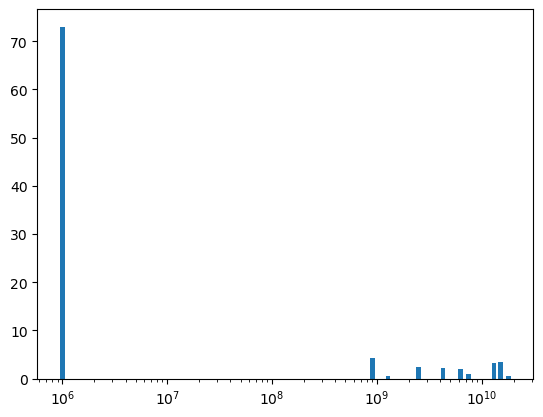

In [374]:
plt.bar(FO['age_j(yr)'],FO['x_j(%)'], width=0.1*FO['age_j(yr)'])
plt.xscale('log')

In [376]:
def read_starlight_best_model(path):
    """
    Lee el bloque:
    ## Synthetic spectrum (Best Model) ##l_obs f_obs f_syn wei Best_f_SSP
      <Nl_obs>   <index_Best_SSP>   [Nl_obs & index_Best_SSP]
      <datos...>
    y devuelve (df, meta), donde meta incluye Nl_obs e index_Best_SSP.
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # 1) Buscar cabecera del bloque
    hdr_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('## Synthetic spectrum (Best Model)'):
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("No se encontró la cabecera de 'Synthetic spectrum (Best Model)'.")

    # 2) Extraer nombres de columnas (aparecen después del segundo '##')
    header_line = lines[hdr_idx].strip()
    # Ejemplo de línea:
    # "## Synthetic spectrum (Best Model) ##l_obs f_obs f_syn wei Best_f_SSP"
    m = re.search(r'##\s*([^#].*)$', header_line)  # toma lo que sigue después del segundo '##'
    if not m:
        raise ValueError("No se pudieron extraer los nombres de columna.")
    raw_cols = m.group(1).strip()
    colnames = re.split(r'\s+', raw_cols)
    # Sanear nombres
    colnames = [re.sub(r'\W+', '_', c).strip('_') for c in colnames]

    # 3) La línea siguiente trae meta: "<Nl_obs> <index_Best_SSP> [Nl_obs & index_Best_SSP]"
    meta_idx = hdr_idx + 1
    meta_line = lines[meta_idx].strip()
    # Parsear primeros dos enteros y lo que hay dentro de corchetes
    ints = re.findall(r'\b\d+\b', meta_line)
    Nl_obs = int(ints[0]) if len(ints) > 0 else None
    index_best = int(ints[1]) if len(ints) > 1 else None
    bracket = re.search(r'\[(.*?)\]', meta_line)
    bracket_label = bracket.group(1).strip() if bracket else None
    meta = {
        "Nl_obs": Nl_obs,
        "index_Best_SSP": index_best,
        "meta_label": bracket_label,
        "meta_raw": meta_line
    }

    # 4) Recolectar filas de datos desde meta_idx+1 hasta que deje de haber numéricas
    data_lines = []
    for j in range(meta_idx + 1, len(lines)):
        row = lines[j].rstrip('\n')
        if not row.strip():
            break
        # filas válidas: comienzan con número (wavelength), separados por espacios
        if re.match(r'^\s*[+-]?\d+(\.\d+)?\b', row):
            data_lines.append(row)
        else:
            # si aparece otra cabecera/sección, cortamos
            if row.strip().startswith(('#', '##')):
                break
            # si no contiene números, cortamos
            if not re.search(r'\d', row):
                break

    if not data_lines:
        raise ValueError("No se encontraron filas de datos del 'Best Model'.")

    # 5) Leer con pandas usando separador de espacios
    df = pd.read_csv(
        StringIO('\n'.join(data_lines)),
        sep=r'\s+',
        engine='python',
        names=colnames
    )

    return df, meta

read_starlight_best_model(name)

(      Synthetic  spectrum     Best   Model    l_obs  f_obs  f_syn  wei  \
 0        3200.0   0.00000  3.10370  -2.000  2.71688    NaN    NaN  NaN   
 1        3201.0   0.00000  3.07747  -2.000  2.69433    NaN    NaN  NaN   
 2        3202.0   0.00000  3.07575  -2.000  2.69235    NaN    NaN  NaN   
 3        3203.0   0.00000  3.07612  -2.000  2.69214    NaN    NaN  NaN   
 4        3204.0   0.00000  3.07650  -2.000  2.69193    NaN    NaN  NaN   
 ...         ...       ...      ...     ...      ...    ...    ...  ...   
 3796     6996.0   0.55460  0.54845  19.078  0.51642    NaN    NaN  NaN   
 3797     6997.0   0.55704  0.54733  19.078  0.51719    NaN    NaN  NaN   
 3798     6998.0   0.54828  0.54430  19.078  0.51710    NaN    NaN  NaN   
 3799     6999.0   0.54799  0.54109  19.078  0.51620    NaN    NaN  NaN   
 3800     7000.0   0.55329  0.54049  19.078  0.51560    NaN    NaN  NaN   
 
       Best_f_SSP  
 0            NaN  
 1            NaN  
 2            NaN  
 3            NaN 

In [ ]:
data = ascii.read('First_runSTARLIGHTmasses.txt')

plt.figure(figsize=(12,6), dpi=100)
plt.bar(data['age_j(yr)'], data['x_j(%)'], width=0.1*data['age_j(yr)'])
plt.xscale('log')
plt.xlabel("Edad estelar (años)")
plt.ylabel("Contribución lumínica (%)")
plt.title("Fracciones x_j(%) por edad")
plt.show()

In [ ]:
data = ascii.read(table = 'First_runSTARLIGHT.txt',
                   data_start = 1, guess = False,
                   names = ['l_obs' ,'f_obs', 'f_syn', 'wei', 'Best_f_SSP'])

data

In [ ]:
plt.figure(figsize=(20,10),dpi=70)
plt.plot(data['l_obs'],data['f_obs'])
plt.plot(data['l_obs'],data['f_syn'])
plt.plot(data['l_obs'],data['Best_f_SSP'])
plt.ylim(0.4,3)
plt.xlim(3600,7000)